## Name : Rajkumar Rajak
## Scholar No : 25215011118
## LAB 1: Human Activity Recognition (HAR) using WISDM

## Problem Definition:

Develop a Deep Learning model to classify human physical activities based on tri-axial accelerometer data. You are provided with the WISDM (Wireless Sensor Data Mining) dataset, which contains accelerometer recordings from 36 users performing 6 distinct activities. Objective: Preprocess the raw time-series data using a Sliding Window technique (segmentation). Build a 1D Convolutiqnal Neural Network (CNN) or LSTM model to classify the activities. Evaluate the model's accuracy and visualize the Confusion Matrix. Target Activities: Walking, Jogging, Upstairs, Downstairs, Sitting, Standing.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

sns.set(style="whitegrid")


In [ ]:
columns = ['user','activity','timestamp', 'x-axis', 'y-axis', 'z-axis']

In [ ]:
columns = ['user','activity','timestamp','x','y','z']

df = pd.read_csv(
    '/content/WISDM_ar_v1.1_raw.txt',
    header=None,
    names=columns,
    sep=',',
    engine='python',
    on_bad_lines='skip'
)

# Remove trailing semicolon
df['z'] = df['z'].astype(str).str.replace(';', '', regex=False)

# Convert to numeric
df[['x','y','z']] = df[['x','y','z']].apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

df.head()


,user,activity,timestamp,x,y,z
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164


In [ ]:
LABELS = ['Downstairs','Jogging','Sitting','Standing','Upstairs','Walking']

activity_map = {label: idx for idx, label in enumerate(LABELS)}
df['activity'] = df['activity'].map(activity_map)

df['activity'].value_counts()


,count
activity,
5,418393
1,336445
4,122869
0,100425
2,59939
3,48394


In [ ]:
N_TIME_STEPS = 90
STEP = 20
N_FEATURES = 3

segments = []
labels = []

for i in range(0, len(df) - N_TIME_STEPS, STEP):
    xs = df['x'].values[i:i+N_TIME_STEPS]
    ys = df['y'].values[i:i+N_TIME_STEPS]
    zs = df['z'].values[i:i+N_TIME_STEPS]

    label = stats.mode(
        df['activity'][i:i+N_TIME_STEPS],
        keepdims=True
    )[0][0]

    segments.append(np.dstack([xs, ys, zs])[0])
    labels.append(label)

X = np.array(segments, dtype=np.float32)
y = to_categorical(labels, num_classes=6)

print(X.shape, y.shape)


(54319, 90, 3) (54319, 6)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D

model = Sequential([
    Conv1D(64, kernel_size=5, padding='same', activation='relu',
           input_shape=(N_TIME_STEPS, N_FEATURES)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=5, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),

    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 90, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 45, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 22, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,958 (429.52 KB)

 Trainable params: 109,318 (427.02 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.8627 - loss: 0.4019 - val_accuracy: 0.9682 - val_loss: 0.0963
Epoch 2/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 35s 51ms/step - accuracy: 0.9752 - loss: 0.0845 - val_accuracy: 0.9760 - val_loss: 0.0779
Epoch 3/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.9809 - loss: 0.0615 - val_accuracy: 0.9875 - val_loss: 0.0385
Epoch 4/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.9854 - loss: 0.0448 - val_accuracy: 0.9911 - val_loss: 0.0315
Epoch 5/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9904 - loss: 0.0314 - val_accuracy: 0.9903 - val_loss: 0.0336
Epoch 6/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.9917 - loss: 0.0262 - val_accuracy: 0.9895 - val_loss: 0.0323
Epoch 7/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.9904 - loss: 0.0318 - val_accuracy: 0.9926 - val_loss: 0.0274
Epoch 8/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9914 - loss: 0.0272 - 

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=LABELS))


340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

  Downstairs       0.98      0.98      0.98      1006
     Jogging       1.00      0.99      1.00      3365
     Sitting       1.00      0.98      0.99       598
    Standing       0.97      0.99      0.98       484
    Upstairs       0.98      0.98      0.98      1228
     Walking       1.00      1.00      1.00      4183

    accuracy                           0.99     10864
   macro avg       0.99      0.99      0.99     10864
weighted avg       0.99      0.99      0.99     10864



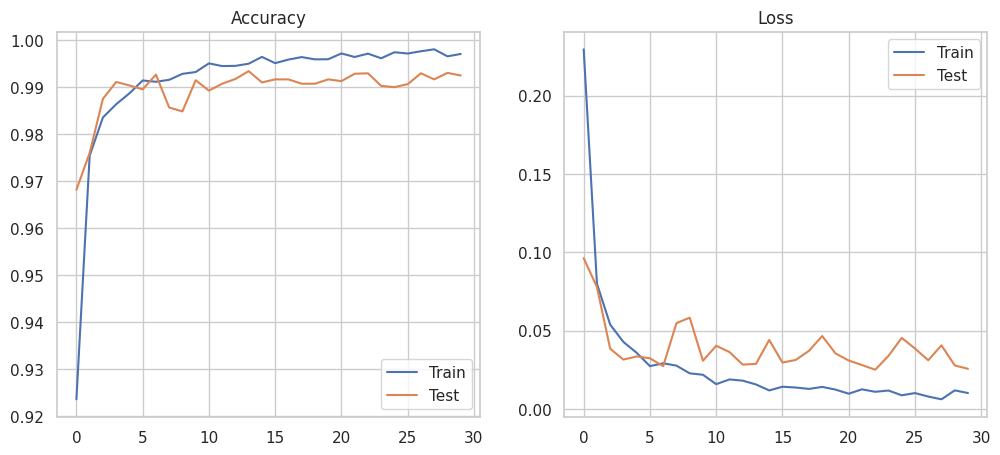

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Loss')
plt.legend()

plt.show()


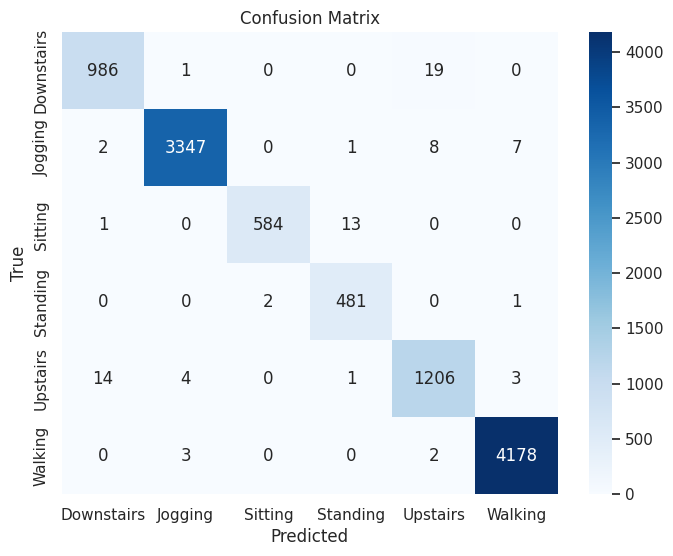

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=LABELS,
            yticklabels=LABELS,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
